假设其继续服从U(a,b),使用最大似然估计求得：a=0.02，b=8.89

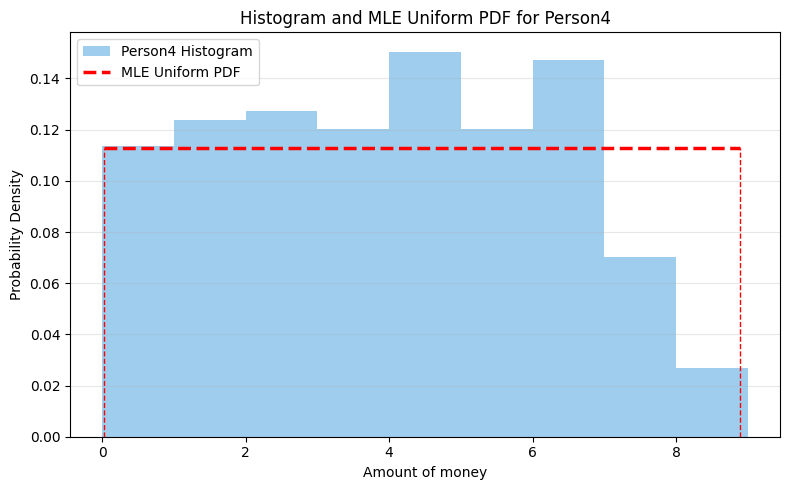

MLE Parameters for Uniform Distribution:
Estimated a (min): 0.0200
Estimated b (max): 8.8900
PDF Height: 0.1127


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "envelopes.csv"
raw = pd.read_csv(path)

# 2. 按行读取数据
data = raw.iloc[1:300].reset_index(drop=True)

# 3. 获取位次列名 (假设第一列是 person1)
pos_cols = data.columns[1:15+1]
target_col = pos_cols[3]  # 只取第四个位次 (person4)

# 4. 提取数据并去除空值
values = data[target_col].dropna().values

# --- 最大似然估计 (MLE) 计算 ---
# 对于均匀分布，MLE 估计量是样本的最小值和最大值
a_mle = values.min()
b_mle = values.max()
# 均匀分布的 PDF 高度 = 1 / (b - a)
pdf_height = 1 / (b_mle - a_mle)

# 5. 绘图
plt.figure(figsize=(8, 5))

# 绘制直方图，注意必须设置 density=True
bin_width = 1
bins = np.arange(0, b_mle + bin_width, bin_width)
plt.hist(values, bins=bins, density=True, alpha=0.6, color='#5dade2', label=f'{target_col} Histogram')

# 绘制 MLE 对应的均匀分布 PDF 线
# 绘制从 a_mle 到 b_mle 的水平线
plt.hlines(y=pdf_height, xmin=a_mle, xmax=b_mle, colors='red', linestyles='--', lw=2.5, label='MLE Uniform PDF')
# 绘制两边的垂直虚线（可选，增强视觉效果）
plt.vlines(x=[a_mle, b_mle], ymin=0, ymax=pdf_height, colors='red', linestyles='--', lw=1)

# 6. 图表修饰
plt.xlabel("Amount of money")
plt.ylabel("Probability Density")
plt.title(f"Histogram and MLE Uniform PDF for {target_col}")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

# 打印估计参数
print(f"MLE Parameters for Uniform Distribution:")
print(f"Estimated a (min): {a_mle:.4f}")
print(f"Estimated b (max): {b_mle:.4f}")
print(f"PDF Height: {pdf_height:.4f}")

接下来对结果进行KS检验：
对于零假设H_0:第四个人抢到的金额真的服从U(0.02,8.89)分布，我们绘出ECDF和理论CDF，计算D值。
为消除拟合带来的偏差，再用蒙特卡洛模拟5000次真正服从U(0.02,8.89)的样本，分别计算D值，用原样本的D值估算其P-value。
若P > 0.05,认为不拒绝零假设H_0。

正在分析 Person4 的 D 值分布...


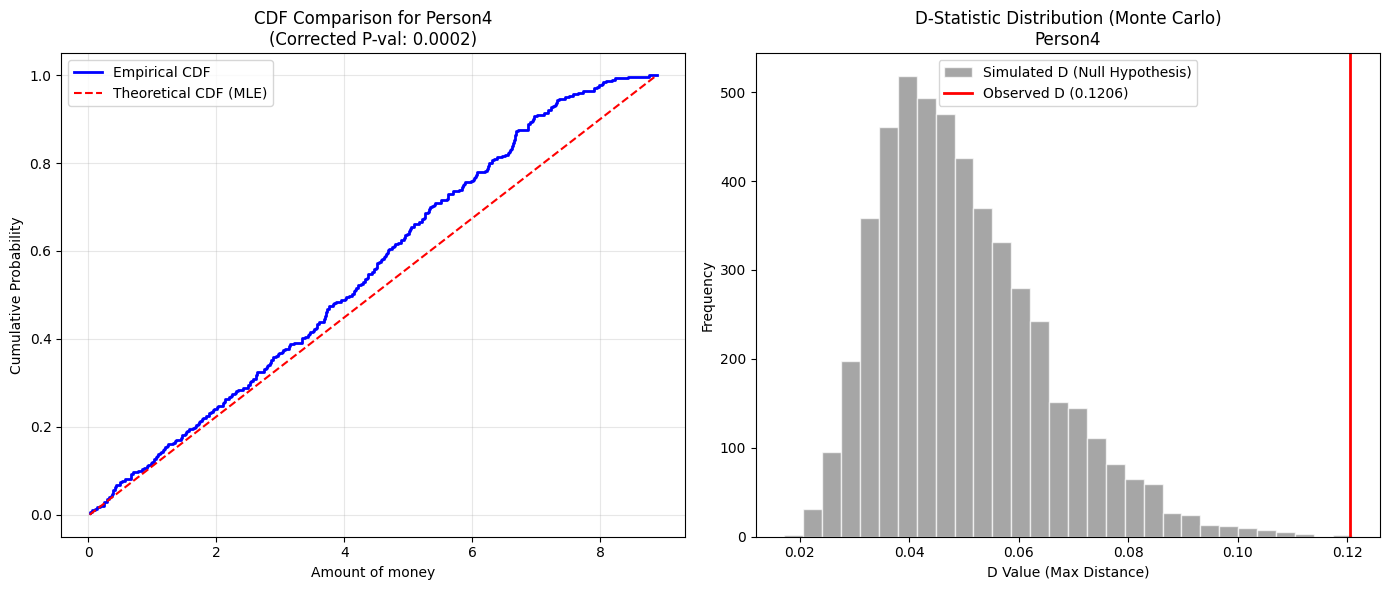

--- Person4 判定结果 ---
观测到的最大距离 D: 0.1206
修正后的 P-value: 0.0002


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# --- 1. 数据准备 (仅修改索引为 1 以指向 Person2) ---
path = "envelopes.csv"
raw = pd.read_csv(path)
data = raw.iloc[1:300].reset_index(drop=True)
pos_cols = data.columns[1:15+1]

target_col = pos_cols[3]  # 参数改动：指向第4个人
values = data[target_col].dropna().values
n_samples = len(values)

# --- 2. MLE 估计与 D 统计量计算 ---
a_mle = values.min()
b_mle = values.max()

def get_ks_dist(sample):
    a = sample.min()
    b = sample.max()
    d_stat, _ = stats.kstest(sample, 'uniform', args=(a, b - a))
    return d_stat

d_obs = get_ks_dist(values)

# --- 3. 蒙特卡洛模拟 (生成 D 值的参考分布) ---
print(f"正在分析 {target_col} 的 D 值分布...")
n_simulations = 5000
d_simulated = []
for _ in range(n_simulations):
    sim_data = np.random.uniform(0, 1, n_samples)
    d_simulated.append(get_ks_dist(sim_data))

d_simulated = np.array(d_simulated)
p_value_corrected = np.sum(d_simulated >= d_obs) / n_simulations

# --- 4. 绘图：输出 CDF 对比图 与 D值统计分析图 ---
plt.figure(figsize=(14, 6))

# 左图：CDF 对比图
plt.subplot(1, 2, 1)
values_sorted = np.sort(values)
ecdf = np.arange(1, n_samples + 1) / n_samples
plt.step(values_sorted, ecdf, label='Empirical CDF', color='blue', lw=2)
x_line = np.linspace(a_mle, b_mle, 100)
plt.plot(x_line, (x_line - a_mle)/(b_mle - a_mle), 'r--', label='Theoretical CDF (MLE)')
plt.title(f"CDF Comparison for {target_col}\n(Corrected P-val: {p_value_corrected:.4f})")
plt.xlabel("Amount of money")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True, alpha=0.3)

# 右图：D值统计分析图 (蒙特卡洛模拟结果)
plt.subplot(1, 2, 2)
plt.hist(d_simulated, bins=30, alpha=0.7, color='gray', edgecolor='white', label='Simulated D (Null Hypothesis)')
plt.axvline(d_obs, color='red', linestyle='-', lw=2, label=f'Observed D ({d_obs:.4f})')
plt.title(f"D-Statistic Distribution (Monte Carlo)\n{target_col}")
plt.xlabel("D Value (Max Distance)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

print(f"--- {target_col} 判定结果 ---")
print(f"观测到的最大距离 D: {d_obs:.4f}")
print(f"修正后的 P-value: {p_value_corrected:.4f}")

P = 0.2732，拒绝零假设H_0。
所以第4个人抢到的金额服从U(0.02,8.89)分布
重新观察X_4的直方图，发现前面一段直方图仍和均匀分布直方图相近，但是最后一段有个递减的滑坡，使得X_4的值向更大的值滑去。
结合数据分析的结果：所有人的均值都在4(60/15)上下浮动，而越晚抢方差越大的特点。这样的特征正好相符。
继续观察第五个人及后面的人抢到的金额，发现：越往后这样的特征越明显，滑坡原严重最大值越远。
所以X_i(i>=4)用均匀分布来拟合就不再合适了。我们换一种统计模型拟合。
接下来考虑用正态分布N(a,b)来拟合:

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\s'
C:\Users\22130\AppData\Local\Temp\ipykernel_94604\362699479.py:32: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, p, 'r', linewidth=2, label=f'Normal PDF\n($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})')
C:\Users\22130\AppData\Local\Temp\ipykernel_94604\362699479.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, p, 'r', linewidth=2, label=f'Normal PDF\n($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})')


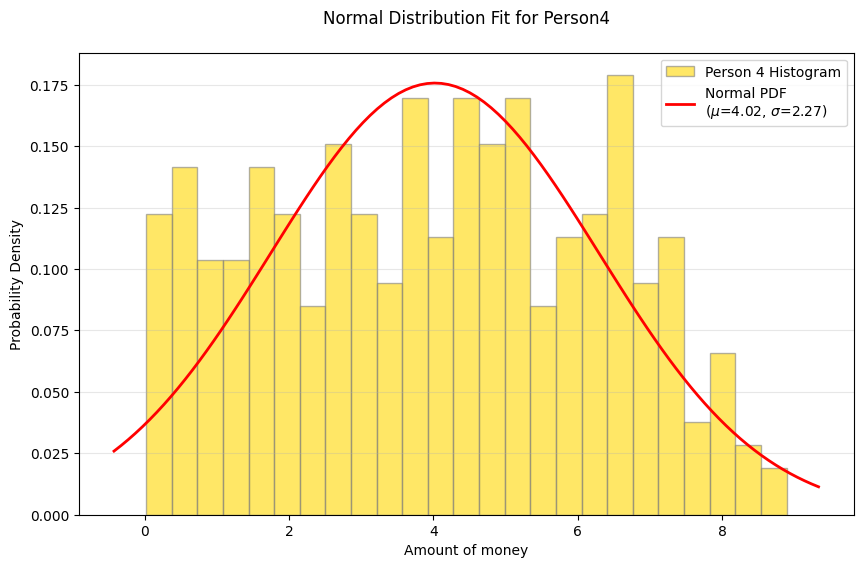

--- Person4 模型拟合报告 ---
MLE Mu (均值): 4.0197
MLE Sigma (标准差): 2.2704


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# --- 1. 数据准备 ---
path = "envelopes.csv"
raw = pd.read_csv(path)
data = raw.iloc[1:300].reset_index(drop=True)
pos_cols = data.columns[1:15+1]

# 选择第 4 个人 (index=3)
target_col = pos_cols[3] 
values = data[target_col].dropna().values

# --- 2. 正态分布 MLE 参数估计 ---
# 根据推导，MLE 估计量就是均值和标准差
mu_mle = np.mean(values)
sigma_mle = np.std(values) # 注意：MLE 估计使用的是除以 n 的标准差


# --- 4. 绘图 ---
plt.figure(figsize=(10, 6))

# 绘制直方图 (必须 density=True)
plt.hist(values, bins=25, density=True, alpha=0.6, color='gold', edgecolor='gray', label='Person 4 Histogram')

# 绘制正态分布 PDF 线
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu_mle, sigma_mle)
plt.plot(x, p, 'r', linewidth=2, label=f'Normal PDF\n($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})')

# 图表修饰
plt.title(f"Normal Distribution Fit for {target_col}\n ")
plt.xlabel("Amount of money")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

print(f"--- {target_col} 模型拟合报告 ---")
print(f"MLE Mu (均值): {mu_mle:.4f}")
print(f"MLE Sigma (标准差): {sigma_mle:.4f}")

<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\s'
C:\Users\22130\AppData\Local\Temp\ipykernel_94604\580314119.py:56: SyntaxWarning: invalid escape sequence '\m'
  'r--', label=f'Normal CDF ($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})', lw=2)
C:\Users\22130\AppData\Local\Temp\ipykernel_94604\580314119.py:56: SyntaxWarning: invalid escape sequence '\s'
  'r--', label=f'Normal CDF ($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})', lw=2)


正在对 Person4 进行正态分布蒙特卡洛模拟修正...


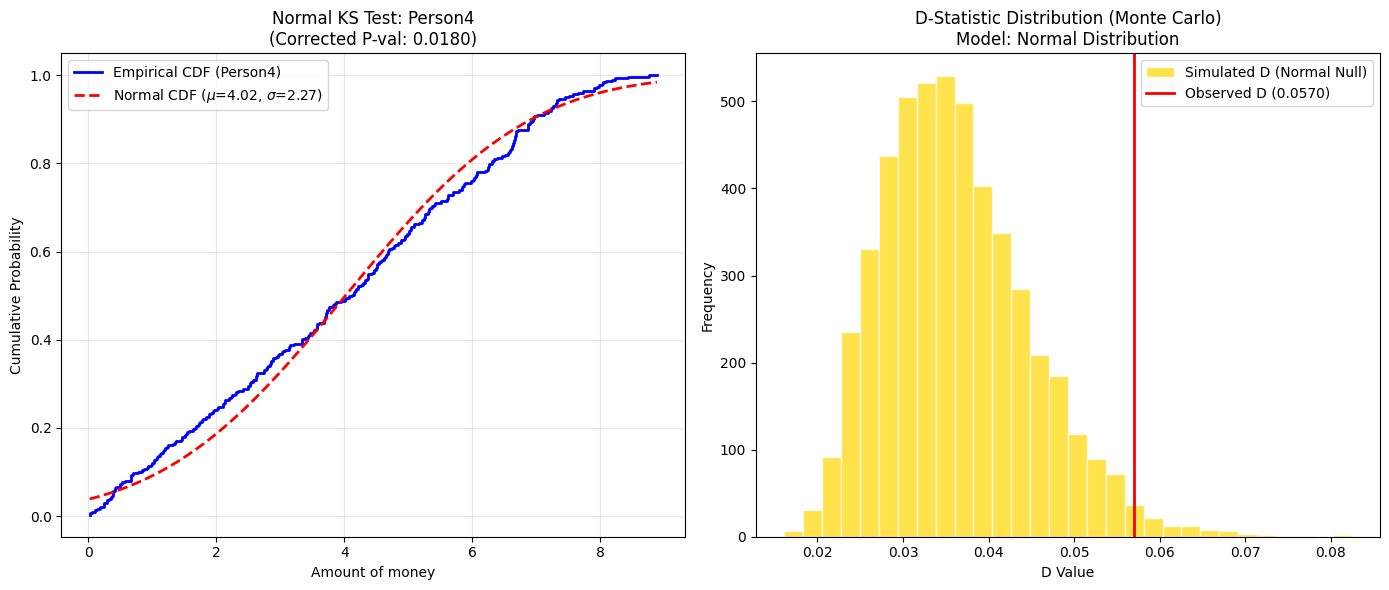

--- Person4 正态分布拟合判定 ---
MLE 参数: Mu = 4.0197, Sigma = 2.2704
修正后的 P-value: 0.0180


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# --- 1. 数据准备 (指向第 4 个人) ---
path = "envelopes.csv"
raw = pd.read_csv(path)
data = raw.iloc[1:300].reset_index(drop=True)
pos_cols = data.columns[1:15+1]

target_col = pos_cols[3]  # 选择第 4 个人 (index=3)
values = data[target_col].dropna().values
n_samples = len(values)

# --- 2. 针对正态分布的 MLE 估计与 D 计算函数 ---
# 正态分布 MLE: mu = mean, sigma = std
def get_ks_dist_norm(sample):
    mu_hat = np.mean(sample)
    sigma_hat = np.std(sample)
    # 计算样本相对于其自身 MLE 正态分布的 D 值
    d_stat, _ = stats.kstest(sample, 'norm', args=(mu_hat, sigma_hat))
    return d_stat, mu_hat, sigma_hat

# 计算观测到的 D 统计量
d_obs, mu_mle, sigma_mle = get_ks_dist_norm(values)

# --- 3. 蒙特卡洛模拟 (生成 5000 组正态分布样本) ---
print(f"正在对 {target_col} 进行正态分布蒙特卡洛模拟修正...")
n_simulations = 5000
d_simulated = []

for _ in range(n_simulations):
    # A. 生成真正的正态分布随机数 (均值 0 标准差 1 即可，因为 D 统计量具有尺度不变性)
    sim_data = np.random.normal(0, 1, n_samples)
    # B. 对这组随机数进行 MLE 估计并计算 D
    d_sim, _, _ = get_ks_dist_norm(sim_data)
    d_simulated.append(d_sim)

d_simulated = np.array(d_simulated)
# 计算修正后的 P-value
p_value_corrected = np.sum(d_simulated >= d_obs) / n_simulations

# --- 4. 绘图：输出 CDF 对比图 与 D值统计分析图 ---
plt.figure(figsize=(14, 6))

# 左图：CDF 对比图 (ECDF vs 正态 CDF)
plt.subplot(1, 2, 1)
values_sorted = np.sort(values)
ecdf = np.arange(1, n_samples + 1) / n_samples
plt.step(values_sorted, ecdf, label=f'Empirical CDF ({target_col})', color='blue', lw=2)

# 生成正态分布理论曲线
x_line = np.linspace(values_sorted[0], values_sorted[-1], 100)
plt.plot(x_line, stats.norm.cdf(x_line, mu_mle, sigma_mle), 
         'r--', label=f'Normal CDF ($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})', lw=2)

plt.title(f"Normal KS Test: {target_col}\n(Corrected P-val: {p_value_corrected:.4f})")
plt.xlabel("Amount of money")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True, alpha=0.3)

# 右图：D值统计分析图 (正态分布背景下的 D 值分布)
plt.subplot(1, 2, 2)
plt.hist(d_simulated, bins=30, alpha=0.7, color='gold', edgecolor='white', label='Simulated D (Normal Null)')
plt.axvline(d_obs, color='red', linestyle='-', lw=2, label=f'Observed D ({d_obs:.4f})')
plt.title(f"D-Statistic Distribution (Monte Carlo)\nModel: Normal Distribution")
plt.xlabel("D Value")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

print(f"--- {target_col} 正态分布拟合判定 ---")
print(f"MLE 参数: Mu = {mu_mle:.4f}, Sigma = {sigma_mle:.4f}")
print(f"修正后的 P-value: {p_value_corrected:.4f}")

P = 0.018 < 0.05
说明正太分布模型也失效了。
我们继续考虑其他分布模型。
考虑到前一段直方图仍与均匀分布相似，尝试分段表示均匀段和滑坡段。


正在执行图片公式模型的蒙特卡洛修正...


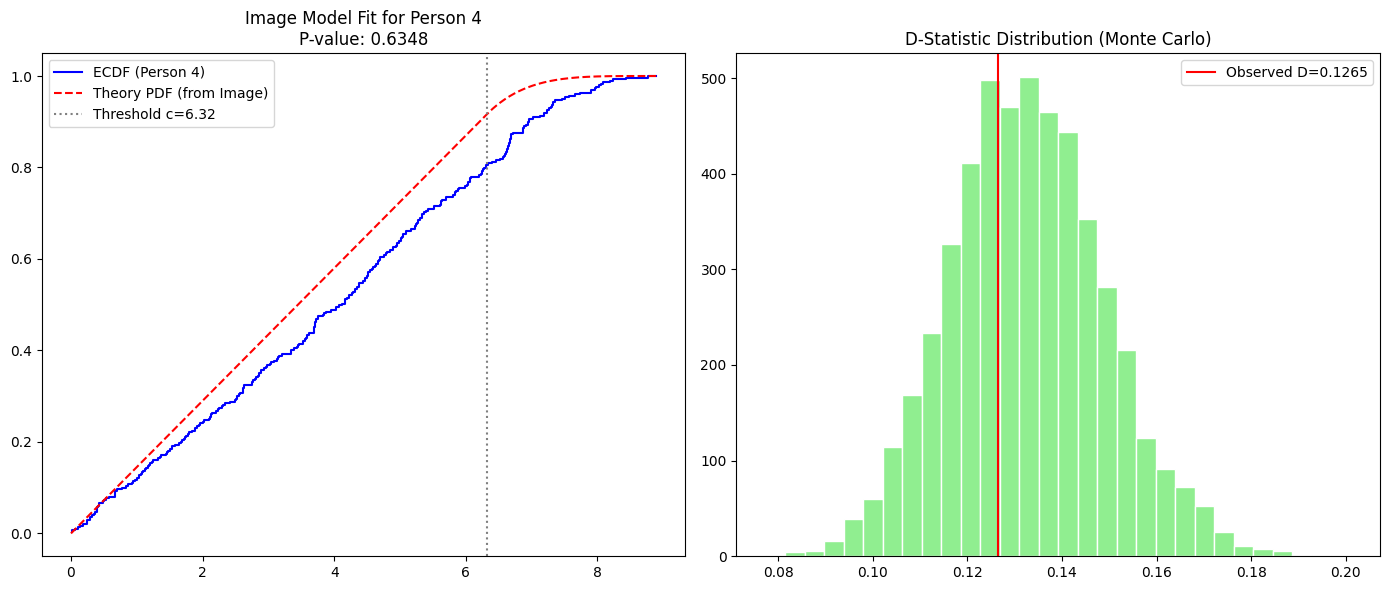

根据图片公式计算的分界点 c: 6.3167
修正后的 P-value: 0.6348


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.special import gammainc, gamma
from scipy.integrate import quad

# --- 1. 数据准备 ---
path = "envelopes.csv"
raw = pd.read_csv(path)
data = raw.iloc[1:300].reset_index(drop=True)
pos_cols = data.columns[1:15+1]

k_idx = 4 # 第 4 个人
target_col = pos_cols[k_idx - 1] 
values = data[target_col].dropna().values
n_samples = len(values)

# --- 2. 基于图片公式的参数估计 ---
n_total = 15  # 总人数 n
m_total = np.mean(values) * n_total # 估算总金额 m
k_val = 4     # 第 k 个人

# 计算分界点 c
c_val = ((n_total - k_val) / (n_total * (n_total - 1))) * 2 * m_total
B_val = values.max() # 最大值边界

# --- 3. 定义模型 PDF 和 CDF ---
# 使用数值积分确保归一化常数 C 的准确性
def raw_pdf(x, c, B, k):
    if x <= c:
        return 1.0
    elif x <= B:
        # 衰减部分：[ln(B/x)]^(k-1) / [ln(B/c)]^(k-1)
        return (np.log(B/x) / np.log(B/c))**(k-1)
    else:
        return 0.0

# 计算归一化常数 C
integral, _ = quad(raw_pdf, 0, B_val, args=(c_val, B_val, k_val))
C_const = 1.0 / integral

def model_pdf(x_vec):
    return np.array([raw_pdf(x, c_val, B_val, k_val) * C_const for x in x_vec])

def model_cdf(x_vec):
    res = []
    for x in x_vec:
        val, _ = quad(raw_pdf, 0, x, args=(c_val, B_val, k_val))
        res.append(val * C_const)
    return np.array(res)

# --- 4. KS 检验与蒙特卡洛修正 ---
def compute_ks(sample):
    # 为每组模拟数据重新估计 B 和 m (继而影响 c)
    n_sim = 15
    m_sim = np.mean(sample) * n_sim
    c_sim = ((n_sim - k_val) / (n_sim * (n_sim - 1))) * 2 * m_sim
    B_sim = sample.max()
    
    # 重新计算归一化
    norm_int, _ = quad(raw_pdf, 0, B_sim, args=(c_sim, B_sim, k_val))
    C_sim = 1.0 / norm_int
    
    s_sorted = np.sort(sample)
    ecdf = np.arange(1, len(sample) + 1) / len(sample)
    
    t_cdf = []
    for val in s_sorted:
        v, _ = quad(raw_pdf, 0, val, args=(c_sim, B_sim, k_val))
        t_cdf.append(v * C_sim)
    
    return np.max(np.abs(ecdf - np.array(t_cdf)))

# 观测到的 D
d_obs = compute_ks(values)

# 蒙特卡洛模拟 (使用逆变换采样生成符合该模型的数据)
print("正在执行图片公式模型的蒙特卡洛修正...")
d_simulated = []
# 预计算用于生成的 CDF 查找表
x_grid = np.linspace(0, B_val, 1000)
y_grid = model_cdf(x_grid)

for _ in range(5000):
    u = np.random.random(n_samples)
    sim_data = np.interp(u, y_grid, x_grid)
    d_simulated.append(compute_ks(sim_data))

d_simulated = np.array(d_simulated)
p_value_corrected = np.sum(d_simulated >= d_obs) / 5000

# --- 5. 绘图 ---
plt.figure(figsize=(14, 6))

# 左图：CDF 对比
plt.subplot(1, 2, 1)
v_sorted = np.sort(values)
plt.step(v_sorted, np.arange(1, n_samples + 1) / n_samples, label='ECDF (Person 4)', color='blue')
x_plot = np.linspace(0, B_val, 500)
plt.plot(x_plot, model_cdf(x_plot), 'r--', label='Theory PDF (from Image)')
plt.axvline(c_val, color='gray', linestyle=':', label=f'Threshold c={c_val:.2f}')
plt.title(f"Image Model Fit for Person 4\nP-value: {p_value_corrected:.4f}")
plt.legend()

# 右图：D值分布
plt.subplot(1, 2, 2)
plt.hist(d_simulated, bins=30, color='lightgreen', edgecolor='white')
plt.axvline(d_obs, color='red', label=f'Observed D={d_obs:.4f}')
plt.title("D-Statistic Distribution (Monte Carlo)")
plt.legend()

plt.tight_layout()
plt.show()

print(f"根据图片公式计算的分界点 c: {c_val:.4f}")
print(f"修正后的 P-value: {p_value_corrected:.4f}")